In [1]:
%pip install tensorflow numpy pandas matplotlib seaborn scikit-metrics kagglehub[pandas-datasets]

  Preparing metadata (setup.py) ... done
  Created wheel for scikit-metrics: filename=scikit_metrics-0.1.0-py3-none-any.whl size=4393 sha256=0def9f9fc39e14717403feb688cb8d1c387463f05763203ca2964a0eab200556
  Stored in directory: /root/.cache/pip/wheels/e1/b6/9d/6a185afb069eb36ef50dcadf4fdd81731a16fc7f9cf1f1fd68
Successfully built scikit-metrics


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ronakp004/autism-spectrum-detection-from-kaggle-zenodo")

print("Path to dataset files:", path)

100%|██████████| 4.93G/4.93G [03:50<00:00, 23.0MB/s]  

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ronakp004/autism-spectrum-detection-from-kaggle-zenodo/versions/14


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50V2, EfficientNetB2, EfficientNetB7, InceptionV3, EfficientNetV2B3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

In [4]:
# Check if GPU detected?
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for i, gpu in enumerate(gpus):
        # Get Specifications Details
        details = tf.config.experimental.get_device_details(gpu)
        gpu_name = details.get('device_name', 'Unknown GPU')
        compute_cap = details.get('compute_capability', 'Unknown')
        
        print(f"\n--- GPU #{i} ---")
        print(f"Name       : {gpu_name}")
        print(f"ID Path    : {gpu.name}")
        print(f"Compute Cap: {compute_cap}")
        
    # Built and Additional information
    print("\n--- Additional Information ---")
    print(f"TensorFlow Version          : {tf.__version__}")
    print(f"Built with CUDA             : {tf.test.is_built_with_cuda()}")
    print(f"Compute Capabilities Build  : {tf.sysconfig.get_build_info()['cuda_compute_capabilities']}")
else:
    print("❌ GPU Not Detected!")


--- GPU #0 ---
Name       : Tesla T4
ID Path    : /physical_device:GPU:0
Compute Cap: (7, 5)

--- Additional Information ---
TensorFlow Version          : 2.19.0
Built with CUDA             : True
Compute Capabilities Build  : ['sm_60', 'sm_70', 'sm_80', 'sm_89', 'compute_90']


In [5]:
ROOT_DIR = path
EPOCHS = 15
BATCH_SIZE = 32
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)

In [13]:
%ls /root/.cache/kagglehub/datasets/ronakp004/autism-spectrum-detection-from-kaggle-zenodo/versions/14

'ASD Data'/
'ASD Facial Image Dataset Combined'/
'Autistic Children Facial Image Dataset'/
'Cleaned Dataset'/
 combined_dataset_duplicates_report.json
'Facial dataset of autistic children'/
'Model results'/
 old_dataset/


In [14]:
%pwd

'/content'

In [16]:
%cp -r '/root/.cache/kagglehub/datasets/ronakp004/autism-spectrum-detection-from-kaggle-zenodo/versions/14/Cleaned Dataset' /content

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

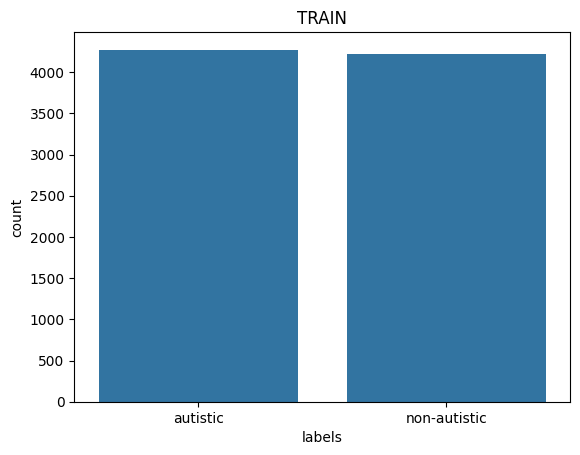

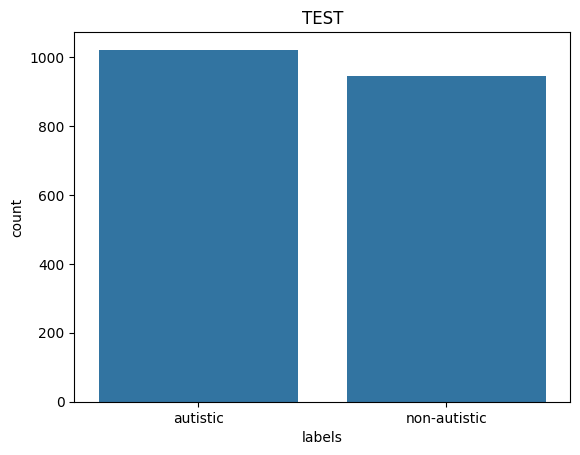

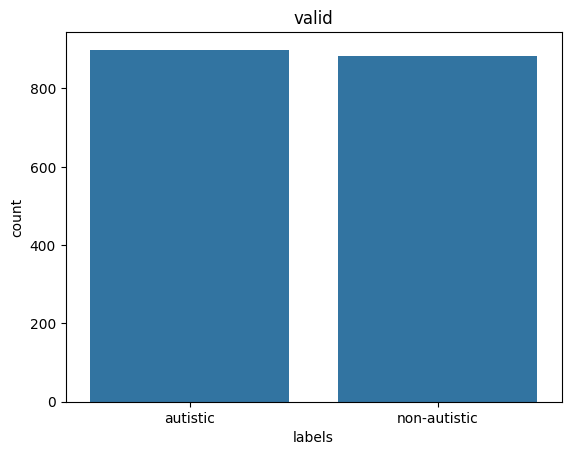

In [6]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_train.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_test.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/cleaned_valid.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
sns.countplot(x='labels',data=valid_df)
plt.title('valid')
plt.show()

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
)
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 8496 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [8]:
test_datagen = ImageDataGenerator(rescale=1./255,)
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1966 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [9]:
valid_datagen = ImageDataGenerator(rescale=1./255,)
valid_gen = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 0 validated image filenames belonging to 0 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1782 invalid image filename(s) in x_col="image_path". These filename(s) will be ignored.
  warnings.warn(


In [10]:
# --- BUILD DUAL-BACKBONE MODEL (FIXED) ---
num_classes = len(train_gen.class_indices)
# 1 single input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2 backbones: instantiate WITHOUT input_shape so they don't create their own Input layers
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet")

# Freeze both initially
mobilenet_backbone.trainable = False
resnet_backbone.trainable = False

# Call both backbones on the SAME input tensor
m_feat = mobilenet_backbone(inputs)      # feature map from MobileNet
r_feat = resnet_backbone(inputs)         # feature map from ResNet

# Pool and combine
m_pool = GlobalAveragePooling2D()(m_feat)
r_pool = GlobalAveragePooling2D()(r_feat)

combined = Concatenate()([m_pool, r_pool])
combined = Dense(512, activation="relu")(combined)
combined = Dropout(0.5)(combined)

outputs = Dense(num_classes, activation="sigmoid")(combined)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

/tmp/ipython-input-1432304885.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ input_layer[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,704,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 0)         │          0 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,527,232 (105.01 MB)

 Trainable params: 1,704,448 (6.50 MB)

 Non-trainable params: 25,822,784 (98.51 MB)

In [11]:
# === CALLBACKS ===
checkpoint = ModelCheckpoint("asr_backbone.keras", monitor="accuracy", save_best_only=True)
earlystop = EarlyStopping(monitor="accuracy", patience=6, restore_best_weights=True)

In [12]:
# === TRAIN ===
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=[checkpoint, earlystop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ValueError: The PyDataset has length 0

In [ ]:
# === EVALUATION ===
loss, acc = model.evaluate(test_gen)
print(f"\n🔥 Model Accuracy: {acc * 100:.2f}%")
print(f"📉 Model Loss: {loss:.4f}")

In [ ]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# Ambil label ground truth dari generator
y_true = test_gen.classes  
class_labels = list(test_gen.class_indices.keys())

# Prediksi model (probability → argmax)
y_pred = model.predict(test_gen)
y_pred_class = np.argmax(y_pred, axis=1)

print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================

cm = confusion_matrix(y_true, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - CNN (ResNet50V2 + MobileNetV2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()